# Projet NLP : Comparaison articles de presse vs articles scientifiques sur le COVID

## Objectif général

Analyser et comparer la manière dont le COVID a été traité dans la presse et dans les articles scientifiques, afin d’identifier différences de ton, de vocabulaire, de sujets et d’évolution dans le temps.

In [36]:
import kagglehub

# Téléchargement du dataset publications
print("\nTéléchargement du dataset publications...")
path_publications = kagglehub.dataset_download("draaslan/covid19-research-papers-dataset")
print("Path to dataset files:", path_publications)


Téléchargement du dataset publications...
Using Colab cache for faster access to the 'covid19-research-papers-dataset' dataset.
Path to dataset files: /kaggle/input/covid19-research-papers-dataset


In [37]:
import pandas as pd
df_news = pd.read_csv('/content/cbc_news.csv')
df_research = pd.read_csv('/kaggle/input/covid19-research-papers-dataset/papers.csv')
df_news['description'].head(1)
df_research.head()


,pmid,doi,journal,country,title,authors,abstract,citation_count,published_at
0,34013297,10.1101/2021.04.27.21256185,medRxiv : the preprint server for health sciences,United States,Pre-pandemic mental and physical health as pre...,"G David Batty, Ian J Deary, Drew Altschul",<Abstract>\n <AbstractText Labe...,0,2021-05-20 00:00:00
1,34013147,10.29337/ijsp.144,International journal of surgery protocols,England,A Study Protocol to Explore and Improve Access...,"Gianina-Ioana Postavaru, Bethan Myers, Tanweer...",<Abstract>\n <AbstractText Labe...,0,2021-05-20 00:00:00
2,34012470,10.1155/2021/5543977,Journal of environmental and public health,United States,Zero-Inflated Time Series Modelling of COVID-1...,"Kassim Tawiah, Wahab Abdul Iddrisu, Killian As...",<Abstract>\n <AbstractText>Disc...,0,2021-05-20 00:00:00
3,34006408,10.1016/j.vaccine.2021.04.054,Vaccine,Netherlands,Thrombocytopenia including immune thrombocytop...,"Kerry J Welsh, Jane Baumblatt, Wambui Chege, R...",<Abstract>\n <AbstractText Labe...,12,2021-05-19 00:00:00
4,34006403,10.1016/j.gerinurse.2021.04.009,"Geriatric nursing (New York, N.Y.)",United States,The impact of COVID-19 on building the next ge...,Barbara Resnick,"<?xml version=""1.0""?>\n<p/>\n",0,2021-05-19 00:00:00


L'objectif est déjà de rassembler les articles par un agrégat temporel. On gardera la donnée du mois et de la semaine.

In [38]:
df_news['date_precise'] = pd.to_datetime(df_news['publish_date'], errors='coerce', format='mixed')
df_news['mois'] = df_news['date_precise'].dt.to_period('M')
df_news['semaine'] = df_news['date_precise'].dt.to_period('W')

In [39]:
import re

def nettoyer_texte_cbc_complet(text):
    if pd.isna(text):
        return ""

    # Supprimer les tags HTML/liens Twitter
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)



    # Supprimer les caractères d'encodage problématiques
    text = text.replace('\xa0', ' ')  # Non-breaking space
    text = text.replace('\u2014', '-')  # Em dash
    text = text.replace('\u2013', '-')  # En dash
    text = text.replace('\u200b', '')

    # Handle escaped single quotes (\\') first
    text = text.replace("\'", "'")

    # Supprimer les backslashes restants (if any)
    text = re.sub(r'\\+', '', text)


    # Supprimer les mentions Twitter et hashtags (optionnel)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)

    # Normaliser les espaces
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

# Application
df_news['text_clean'] = df_news['text'].apply(nettoyer_texte_cbc_complet)

In [40]:
display(df_news['text'][0])

'Lily Overacker and Laurell Pallot start each gay-straight alliance meeting with everyone introducing themselves, saying their pronouns and sharing highs and lows of the week. Except lately it\'s been through email chains instead of in-person for the Grade 12 students in Lacombe, Alta. Such school clubs are meant to provide safe spaces for LGBTQ students and their allies. Students, teachers and community groups are working to ensure that support is still available as the COVID-19 pandemic keeps kids out of school. "It\'s definitely harder because you want to be able to see those people and be around them," said Overacker, 18. "But I think we are making the best out of the situation that we can and focusing on making sure that kids still know that there\'s people there to support them." Overacker and Pallot want to hold a virtual end-of-year celebration for LGBTQ students. "We\'re thinking it\'ll be over Zoom and we want it to be Alberta-wide," said Pallot, 17. She said community groups

In [41]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [42]:
import re
def nettoyer_texte(s):
    s = str(s)
    s = re.sub(r'<.*?>', '', s)  # supprimer balises
    s = re.sub(r'\s+', ' ', s)   # réduire espaces multiples à 1
    s = re.sub(r'\n\s*\n\s*\n+', '\n\n', s)  # Réduire les sauts de ligne multiples
    s = re.sub(r'[ \t]+', ' ', s)  # Espaces multiples en un seul
    s = re.sub(r' +\n', '\n', s)  # Espaces en fin de ligne
    s = re.sub(r'\n +', '\n', s)  # Espaces en début de ligne

    # 9. Supprimer les parenthèses vides ou avec juste des espaces
    s = re.sub(r'\(\s*\)', '', s)

    # 10. Nettoyer la ponctuation défectueuse
    s = re.sub(r'\.+', '.', s)  # Points multiples
    s = re.sub(r',+', ',', s)  # Virgules multiples
    s = re.sub(r'\s+([,.;:!?])', r'\1', s)  # Espaces avant ponctuation
    return s.strip()              # enlever espaces début/fin

df_research['texte_nettoye'] = df_research['abstract'].apply(nettoyer_texte)
df_research['texte_nettoye'] = df_research['texte_nettoye'].str.split('Copyright').str[0].str.strip()

In [43]:
import nltk
# from nltk.tokenize import sent_tokenize, word_tokenize # For tokenizing the text
# from nltk.corpus import stopwords # For removing the stopwords

# Download some useful data files from NLTK
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('treebank')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /r

True

In [44]:
df_research['tokens'] = df_research['texte_nettoye'].apply(lambda x: nltk.word_tokenize(str(x)))

In [45]:
import string
stop_words = nltk.corpus.stopwords.words('english')
excluded_tokens = list(stop_words) + list(string.punctuation) + ["'s", "'"]
def filtre_stop_words(tokens):
    tokens_filtered = [t for t in tokens if t.lower() not in excluded_tokens]
    return tokens_filtered
df_research['tokens_filtered'] = df_research['tokens'].apply(filtre_stop_words)

In [46]:
tokens = []
for d in df_research["tokens_filtered"]:
    tokens.extend(d)
print('Total Tokens: \t', len(tokens))
print('Total Tokens Uniques: \t', len(set(tokens)))

Total Tokens: 	 16160860
Total Tokens Uniques: 	 382901


In [47]:
fq = nltk.probability.FreqDist(tokens)
topwords = fq.most_common(20)
topwords

[('COVID-19', 318247),
 ('patients', 181623),
 ('pandemic', 108539),
 ('SARS-CoV-2', 94868),
 ('disease', 82667),
 ('study', 76989),
 ('health', 76161),
 ('2020', 69980),
 ('infection', 58685),
 ('coronavirus', 56957),
 ('care', 51744),
 ('clinical', 50251),
 ('risk', 48515),
 ('severe', 45701),
 ('data', 45344),
 ('2019', 43103),
 ('cases', 42218),
 ('respiratory', 40829),
 ('associated', 38970),
 ('may', 38269)]

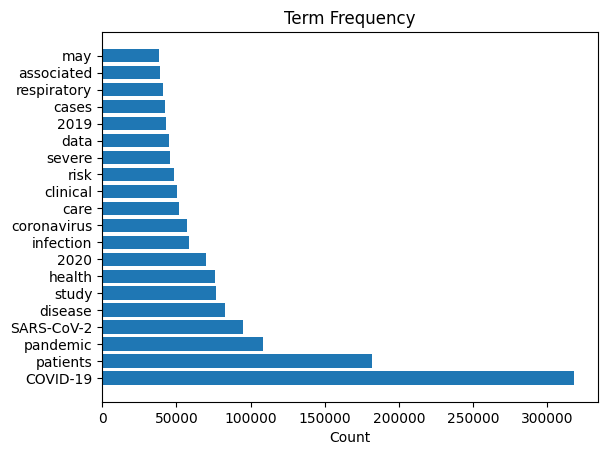

In [48]:
%matplotlib inline
import matplotlib.pyplot as plt

top10_words = [it[0] for it in topwords]
top10_counts = [it[1] for it in topwords]
plt.barh(top10_words, top10_counts)
plt.title('Term Frequency');
plt.xlabel('Count');

In [49]:
titles_with_sentiment = []
for title in df_research["title"]:
    if pd.isna(title):  # si c'est NaN
        title = ""
    else:
        title = str(title)

    ss = analyzer.polarity_scores(title)
    _d = {"title": title}
    _d.update(ss)
    titles_with_sentiment.append(_d)

df = pd.DataFrame(titles_with_sentiment)
print(df)

NameError: name 'analyzer' is not defined

In [50]:
ax1 = df.plot.scatter(x='neg', y='pos', c='compound', colormap='RdYlGn')

NameError: name 'df' is not defined

In [51]:
import matplotlib.pyplot as plt

# grouper par jour : moyenne des sentiments et nombre d'articles
dfD = df.groupby(pd.PeriodIndex(df_research['date'], freq="D")).agg(
    sentiment_mean=('sentiment', 'mean'),
    count=('sentiment', 'size')
)

# tracer
fig, ax1 = plt.subplots()

# courbe du sentiment moyen
ax1.plot(dfD.index.to_timestamp(), dfD['sentiment_mean'], color="blue", label="Sentiment moyen")
ax1.set_ylabel("Sentiment moyen", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# axe secondaire pour le nombre d'articles
ax2 = ax1.twinx()
ax2.plot(dfD.index.to_timestamp(), dfD['count'], color="red", label="Nombre d'articles")
ax2.set_ylabel("Nombre d'articles", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Évolution du sentiment moyen et du nombre d'articles par jour")
fig.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [52]:
dfR = dfD.rolling(20, center=False).mean()
print(dfR)
dfR.plot(color="red")

NameError: name 'dfD' is not defined

In [53]:
# Charger le modèle
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convertir en liste pour le modèle
texts = df_news['text_clean'].tolist()

# Créer les embeddings (ça peut prendre quelques minutes)
embeddings = model.encode(texts, show_progress_bar=True)

print(f"Shape des embeddings: {embeddings.shape}")  # (6788, 384)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/213 [00:00<?, ?it/s]

Shape des embeddings: (6788, 384)


In [54]:
texts_research = df_research['texte_nettoye'].tolist()

# Créer les embeddings (ça peut prendre quelques minutes)
embeddings_research = model.encode(texts_research, show_progress_bar=True)

print(f"Shape des embeddings: {embeddings_research.shape}")  # (6788, 384)

Batches:   0%|          | 0/5166 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [55]:
df_research['date_precise'] = pd.to_datetime(df_research['published_at'], errors='coerce', format='mixed')
df_research['mois'] = df_research['date_precise'].dt.to_period('M')
df_research['semaine'] = df_research['date_precise'].dt.to_period('W')

In [60]:
publications_par_mois_news = df_news.groupby('M').size().reset_index(name='nombre_publications')
print("Nombre de publications de presse par mois:")
display(publications_par_mois_news)

publications_par_mois_research = df_research.groupby('mois').size().reset_index(name='nombre_publications')
print("\nNombre de publications de recherche par mois:")
display(publications_par_mois_research)

KeyError: 'M'

In [61]:
# 1. Voir la distribution complète d'abord
print("Distribution complète:")
print(df_news['mois'].value_counts().sort_index())

# 2. Filtrer pour garder seulement 2020 et après
df_news_covid = df_news[df_news['publish_date'] >= '2020-01-01'].copy()

print(f"\nAvant filtrage: {len(df_news)} articles")
print(f"Après filtrage: {len(df_news_covid)} articles")
print(f"Articles supprimés: {len(df_news) - len(df_news_covid)}")

# 3. Vérifier la nouvelle distribution
print("\nDistribution après filtrage:")
print(df_news_covid['mois'].value_counts().sort_index())

# 4. Filtrer aussi les embeddings correspondants
covid_indices = df_news_covid.index.tolist()
embeddings_covid = embeddings[covid_indices]

print(f"\nShape embeddings filtrés: {embeddings_covid.shape}")

# 5. Remplacer les variables pour la suite
df_news = df_news_covid
embeddings = embeddings_covid

Distribution complète:
mois
2020-01     182
2020-02     356
2020-03    2402
2020-04    3570
2020-05     263
Freq: M, Name: count, dtype: int64

Avant filtrage: 6773 articles
Après filtrage: 6773 articles
Articles supprimés: 0

Distribution après filtrage:
mois
2020-01     182
2020-02     356
2020-03    2402
2020-04    3570
2020-05     263
Freq: M, Name: count, dtype: int64


IndexError: index 6773 is out of bounds for axis 0 with size 6773

In [62]:
# 2. Vérifier la distribution
print("Articles par mois:")
print(df_news['mois'].value_counts().sort_index())

# 3. Calculer l'embedding moyen par mois
def calculate_monthly_embeddings(df, embeddings):
    monthly_embeddings = {}
    monthly_counts = {}

    # Reset index to ensure alignment with embeddings
    df_reset = df.reset_index(drop=True)

    for month, group in df_reset.groupby('mois'):
        # Indices des articles de this month
        indices = group.index.tolist()

        # Embeddings correspondants
        month_embeddings = embeddings[indices]

        # Moyenne des embeddings
        avg_embedding = np.mean(month_embeddings, axis=0)
        monthly_embeddings[month] = avg_embedding
        monthly_counts[month] = len(indices)

        print(f"{month}: {len(indices)} articles")


    return monthly_embeddings, monthly_counts

# 4. Appliquer le calcul
monthly_cbc_embeddings, monthly_counts = calculate_monthly_embeddings(df_news, embeddings)
monthly_cbc_embeddings_research, monthly_counts_research = calculate_monthly_embeddings(df_research, embeddings_research)

# 5. Convertir en DataFrame
monthly_df = pd.DataFrame.from_dict(monthly_cbc_embeddings, orient='index')
monthly_df_research = pd.DataFrame.from_dict(monthly_cbc_embeddings_research, orient='index')

# 6. Nommer les colonnes
monthly_df.index.name = 'mois'
monthly_df.columns = [f'embedding_{i}' for i in range(monthly_df.shape[1])]

print(f"\nShape embeddings mensuels: {monthly_df.shape}")
print(f"Shape embeddings mensuels de recherche: {monthly_df_research.shape}")
print(f"Période couverte: {monthly_df.index.min()} à {monthly_df.index.max()}")
print(f"Période couverte: {monthly_df_research.index.min()} à {monthly_df_research.index.max()}")

# 6. Sauvegarder
monthly_df.to_pickle('monthly_cbc_embeddings.pkl')
np.save('monthly_cbc_embeddings.npy', monthly_df.values)

print("✅ Embeddings mensuels calculés et sauvegardés !")

Articles par mois:
mois
2020-01     182
2020-02     356
2020-03    2402
2020-04    3570
2020-05     263
Freq: M, Name: count, dtype: int64
2020-01: 182 articles
2020-02: 356 articles
2020-03: 2402 articles
2020-04: 3570 articles
2020-05: 263 articles


NameError: name 'embeddings_research' is not defined

In [63]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# 1. Calculer les embeddings mensuels pour les deux corpus
def calculate_monthly_embeddings(df, embeddings, corpus_name):
    monthly_embeddings = {}
    monthly_counts = {}

    for month, group in df.groupby('mois'):
        indices = group.index.tolist()
        month_embeddings = embeddings[indices]
        avg_embedding = np.mean(month_embeddings, axis=0)
        monthly_embeddings[month] = avg_embedding
        monthly_counts[month] = len(indices)
        print(f"{corpus_name} {month}: {len(indices)} articles")

    return monthly_embeddings, monthly_counts

# CBC mensuels
print("=== CBC par mois ===")
monthly_cbc, counts_cbc = calculate_monthly_embeddings(df_news, embeddings, "CBC")

# PMC mensuels (assumant que vous avez df_pmc)
print("\n=== PMC par mois ===")
monthly_pmc, counts_pmc = calculate_monthly_embeddings(df_research, embeddings_research, "PMC")

# 2. Comparer CBC vs PMC pour chaque mois commun
common_months = set(monthly_cbc.keys()) & set(monthly_pmc.keys())
common_months = sorted(common_months)

similarities_cbc_pmc = []
months_compared = []

for month in common_months:
    cbc_emb = monthly_cbc[month].reshape(1, -1)
    pmc_emb = monthly_pmc[month].reshape(1, -1)

    sim = cosine_similarity(cbc_emb, pmc_emb)[0][0]
    similarities_cbc_pmc.append(sim)
    months_compared.append(month)
    print(f"{month}: Similarité CBC-PMC = {sim:.3f}")

# 3. Visualiser
plt.figure(figsize=(15, 6))
plt.plot(months_compared, similarities_cbc_pmc, marker='o', linewidth=2, markersize=8)
plt.title('Similarité thématique CBC vs PMC par mois')
plt.xlabel('Mois')
plt.ylabel('Similarité cosinus')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSimilarité moyenne CBC-PMC: {np.mean(similarities_cbc_pmc):.3f}")

=== CBC par mois ===
CBC 2020-01: 182 articles
CBC 2020-02: 356 articles


IndexError: index 6773 is out of bounds for axis 0 with size 6773